In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:
def p3_from_spherical(p, theta, phi):
    """
    Convert spherical momentum (p, theta, phi) → Cartesian 3-vector
    θ = azimuth, φ = polar (as in your generator)
    """
    px = p * np.sin(phi) * np.cos(theta)
    py = p * np.sin(phi) * np.sin(theta)
    pz = p * np.cos(phi)
    return np.array([px, py, pz])

In [ ]:
def invariant_mass(v1, v2):
    E1, p1, th1, ph1, m1= v1
    E2, p2, th2, ph2, m2 = v2

    p1_vec = p3_from_spherical(p1, th1, ph1)
    p2_vec = p3_from_spherical(p2, th2, ph2)

    P_tot = np.array([
        E1 + E2,
        *(p1_vec + p2_vec)
    ])

    M2 = P_tot[0]**2 - np.dot(P_tot[1:], P_tot[1:])
    return np.sqrt(max(M2, 0.0))

In [ ]:
def E_m1(M, m1, m2):
    return (M**2 + m1**2 - m2**2) / (2*M)

def p_m1(M, m1, m2):
    return np.sqrt((M**2 + m1**2 - m2**2)**2 - 4*(M**2)*(m1**2)) / (2*M)

In [ ]:
def generate_two_body(M, m1, m2):
    theta = random.uniform(0, 2*np.pi)
    phi = random.uniform(0, np.pi)

    theta2 = (np.pi + theta) % (2*np.pi)
    phi2 = np.pi - phi

    E1 = E_m1(M, m1, m2)
    E2 = E_m1(M, m2, m1)

    p1 = p_m1(M, m1, m2)
    p2 = p_m1(M, m2, m1)

    v1 = np.array([E1, p1, theta, phi, m1])
    v2 = np.array([E2, p2, theta2, phi2, m2])

    return v1, v2

In [ ]:
M_JPSI = 3.0969
M_PHI = 1.01946
M_PSIP = 3.686
M_P = 0.93827
M_U = 0.10566
M_E = 0.000511
M_K = 0.493677


def generate_Jpsi_pp(): return generate_two_body(M_JPSI, M_P, M_P)
def generate_Jpsi_uu(): return generate_two_body(M_JPSI, M_U, M_U)
def generate_Jpsi_ee(): return generate_two_body(M_JPSI, M_E, M_E)
def generate_phi_kk(): return generate_two_body(M_PHI, M_K, M_K)
def generate_psip_uu(): return generate_two_body(M_PSIP, M_U, M_U)

In [ ]:
def sample_process(generator, N=20000, smear=False):
    masses = []

    for _ in range(N):
        v1, v2 = generator()

        if smear:
            v1 = smear_event(v1)
            v2 = smear_event(v2)

        masses.append(invariant_mass(v1, v2))

    return np.array(masses)

In [ ]:
def sample_exponential_truncated(m_min, m_max, scale):
    while True:
        x = np.random.exponential(scale=scale)
        if m_min <= x <= m_max:
            return x


def generate_two_body_varmass(mass, m1):
    return generate_two_body(mass, m1, m1)


def generate_gammagamma_uu():
    M = sample_exponential_truncated(2*M_U, 7, 1)
    return generate_two_body_varmass(M, M_U)

def generate_gammagamma_ee():
    M = sample_exponential_truncated(2*M_E, 7, 1)
    return generate_two_body_varmass(M, M_E)

def generate_gammagamma_kk():
    M = sample_exponential_truncated(2*M_K, 7, 1)
    return generate_two_body_varmass(M, M_K)

In [ ]:
N = 10000

processes = {
    "J/psi → pp": generate_Jpsi_pp,
    "J/psi → uu": generate_Jpsi_uu,
    "J/psi → ee": generate_Jpsi_ee,
    "phi → KK": generate_phi_kk,
    "psip → uu": generate_psip_uu,
    "γγ → uu": generate_gammagamma_uu,
    "γγ → ee": generate_gammagamma_ee,
    "γγ → KK": generate_gammagamma_kk,
}

In [ ]:
data_raw1 = {name: sample_process(gen, N, smear=False)
            for name, gen in processes.items()}

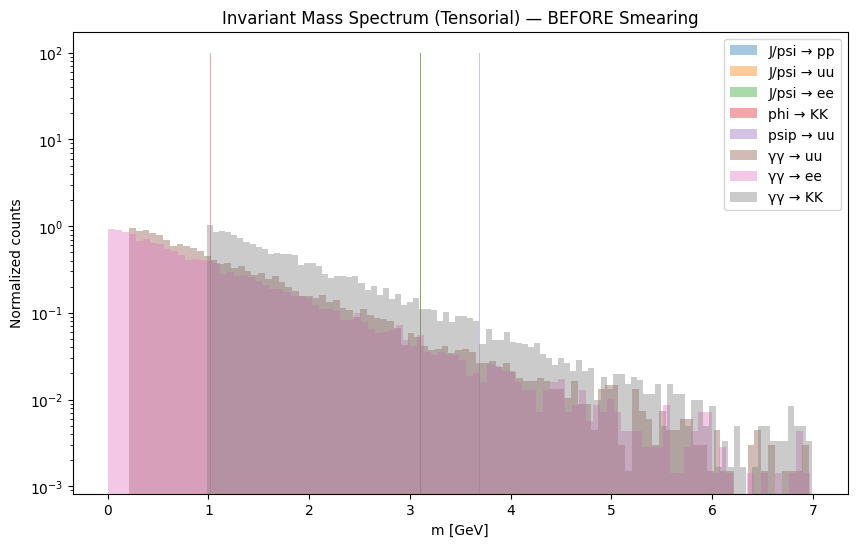

In [ ]:
plt.figure(figsize=(10,6))

for name, masses in data_raw1.items():
    plt.hist(masses, bins=100, alpha=0.4, label=name, density=True)

plt.title("Invariant Mass Spectrum (Tensorial) — BEFORE Smearing")
plt.xlabel("m [GeV]")
plt.yscale("log")
plt.ylabel("Normalized counts")
plt.legend()
plt.show()

In [ ]:
def smear_event(v, sigma_E=0.02, sigma_p=0.02, sigma_ang=0.001):
    """
    Smear a single event: [E, p, theta, phi]
    """

    E, p, th, ph = v

    # energy and momentum magnitude smearing (Gaussian, fractional)
    E_s = E * np.random.normal(1.0, sigma_E)
    p_s = p * np.random.normal(1.0, sigma_p)

    # angular smearing
    th_s = th + np.random.normal(0.0, sigma_ang)
    ph_s = ph + np.random.normal(0.0, sigma_ang)

    # keep angles physical
    th_s = np.clip(th_s, 0.0, np.pi)
    ph_s = ph_s % (2 * np.pi)

    return np.array([E_s, p_s, th_s, ph_s])

In [ ]:
def smear_event_momentum_only(v, mass=0.0, sigma_p=0.02):
    """
    Momentum-based smearing only.

    v = [E, p, theta, phi]
    mass = particle mass (set 0 for ultra-relativistic approximation)
    """

    E, p, th, ph = v

    # convert spherical -> Cartesian momentum
    px = p * np.sin(th) * np.cos(ph)
    py = p * np.sin(th) * np.sin(ph)
    pz = p * np.cos(th)

    p_vec = np.array([px, py, pz])

    # smear each momentum component
    p_vec_s = p_vec * (1.0 + np.random.normal(0.0, sigma_p, size=3))

    # recompute momentum magnitude
    p_s = np.linalg.norm(p_vec_s)

    # avoid division issues
    if p_s == 0:
        return np.array([0.0, 0.0, th, ph])

    # recompute angles
    th_s = np.arccos(np.clip(p_vec_s[2] / p_s, -1.0, 1.0))
    ph_s = np.arctan2(p_vec_s[1], p_vec_s[0])

    # reconstruct energy consistently
    E_s = np.sqrt(p_s**2 + mass**2)

    return np.array([E_s, p_s, th_s, ph_s])

In [ ]:
def smear_event_resolution(v, a=0.01, b=0.001):
    """
    Resolution-driven smearing:
    dp/p = a + b p

    v = [E, p, theta, phi]
    """

    E, p, th, ph, m = v

    # resolution
    sigma_p = p * (a + b * p)

    # smear momentum magnitude
    p_s = np.random.normal(p, sigma_p)

    # enforce positivity
    p_s = max(p_s, 0.0)

    # angles unchanged (simple detector model)
    th_s = th
    ph_s = ph

    # reconstruct energy (massless approximation)
    E_s = p_s

    return np.array([E_s, p_s, th_s, ph_s, m])

In [ ]:
def smear_event_resolution(v, a=0.01, b=0.001):

    E, p, th, ph, m = v

    sigma_p = p * (a + b * p)

    p_s = np.random.normal(p, sigma_p)
    p_s = max(p_s, 0.0)

    th_s = th
    ph_s = ph

    # correct energy reconstruction
    E_s = np.sqrt(p_s**2 + m**2)

    return np.array([E_s, p_s, th_s, ph_s, m])

In [ ]:
def sample_process(generator, N=20000, smear=False):
    masses = []

    for _ in range(N):
        v1, v2 = generator()

        # apply detector smearing AFTER generation
        if smear:
            # v1 = smear_event_momentum_only(v1)
            # v2 = smear_event_momentum_only(v2)

            v1 = smear_event_resolution(v1)
            v2 = smear_event_resolution(v2)

        masses.append(invariant_mass(v1, v2))

    return np.array(masses)

In [ ]:
data_raw2 = {
    name: sample_process(gen, N=10000, smear=False)
    for name, gen in processes.items()
}

In [ ]:
data_smeared = {
    name: sample_process(gen, N=10000, smear=True)
    for name, gen in processes.items()
}

In [ ]:
def plot_only_smeared(data_smeared, bins=100):
    plt.figure(figsize=(10,6))

    for name, masses in data_smeared.items():
        plt.hist(
            masses,
            bins=bins,
            histtype='step',
            density=True,
            linewidth=1.5,
            label=name
        )

    plt.xlabel("Invariant mass [GeV]")
    plt.ylabel("Normalized counts")
    plt.title("Smeared Invariant Mass Distributions")
    plt.yscale("log")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

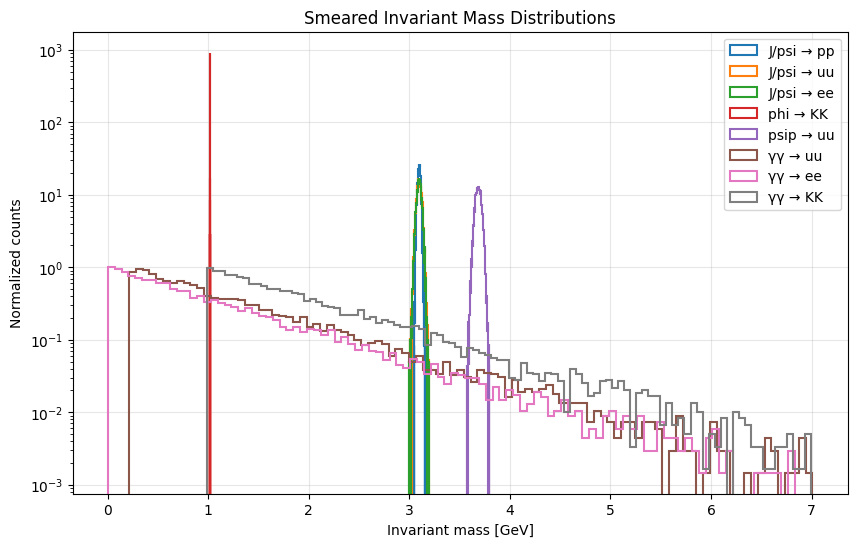

In [ ]:
plot_only_smeared(data_smeared)

In [1]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
iris = load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)
for score, name in zip(rnd_clf.feature_importances_, iris.data.columns):
    print(round(score, 2), name)

0.11 sepal length (cm)
0.02 sepal width (cm)
0.44 petal length (cm)
0.42 petal width (cm)
